# Hospitality RL Environment — OpenEnv Challenge Submission

**116-task, 33-tool, multi-turn, safety-critical service-industry environment built from real hot-pot-restaurant operations.**

This notebook is the single entry point to the submission. It:

1. Introduces the environment — scope, task categories, tool surface, real-operations grounding.
2. Shows the **main result**: a triple-family × two-capacity-tier null (Qwen 7B / 14B, Llama 3.1 8B, Gemma 2 9B — six open-weight configs clustered in a 0.056-wide band, Claude Sonnet 4.5 alone at +0.314).
3. Breaks the null down per category, including the hero counter-example (Gemma beating Claude on `server_food_safety` by doing **nothing**).
4. Shows **v3 overfit evidence** — driving training loss 12× lower moved held-out reward +0.003.
5. Lists the 8 structural design limitations (P0–P3) and how V2 fixes each.
6. Demonstrates loading the published v1 LoRA adapter from the Hub.

Everything renders from **pre-computed JSON artifacts in `evals/` and `eval_results/`** — no GPU required to reproduce the story. GPU-gated cells at the end are clearly labeled.

**Repo:** <https://github.com/binleiwang/openenv-hospitality> · **Adapter:** <https://huggingface.co/binleiwang/qwen2.5-7b-hospitality-sft> · **Challenge:** OpenEnv 2026 (Meta PyTorch × Hugging Face × Unsloth)


## 0. Setup

No GPU needed for §1–§6. Just `pandas` + `matplotlib` to render the tables and plot.
The live-adapter demo in §7 is GPU-gated and clearly marked.


In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
EVALS = ROOT / "evals"
CLAUDE = ROOT / "eval_results"

# Sanity check all six heldout evals are present
heldouts = {
    "Qwen 7B base":        EVALS / "eval_heldout_base_stratified.json",
    "Qwen 7B + v1 SFT":    EVALS / "eval_heldout_v1_stratified.json",
    "Qwen 7B + v3 SFT":    EVALS / "eval_heldout_v3.json",
    "Qwen 14B base":       EVALS / "eval_heldout_base_14b_stratified.json",
    "Llama 3.1 8B base":   EVALS / "eval_heldout_base_llama_stratified.json",
    "Gemma 2 9B base":     EVALS / "eval_heldout_base_gemma_stratified.json",
}
for label, p in heldouts.items():
    assert p.exists(), f"missing: {p}"
print("All 6 held-out eval artifacts present.")


All 6 held-out eval artifacts present.


## 1. Environment walkthrough

### 1.1 What's in the box

| Dimension | Count |
|---|---|
| Tasks | **116** (101 base + 15 kitchen-coordination variants) |
| Task categories | 11 (host_phone, host_seating, host_walkin, server_food_safety, server_promotion, server_food_issue, server_billing, server_celebration, server_incident, server_special_policy, server_misc) |
| Agent tools | **33** (menu lookup, reservation CRUD, allergy verification, billing, escalation, incident logging, …) |
| User-simulator tools | **8** |
| Policy document | 466 lines of operational SOPs (discount limits, allergen handling, service recovery, escalation ladders) |
| Scoring | **ACTION** (required tool calls) + **ENV_ASSERTION** (DB state checks) — fully deterministic, no LLM-as-judge |

All 116 tasks are derived from **actual customer interactions and operational incidents** at a real hot-pot restaurant. Seating configuration, staff hierarchy, menu/pricing, and policies map to operational reality — not fabricated for benchmarking.

> Why hot pot: interactive-tabletop-cooking formats compress every hospitality pain-point into one service unit — allergen disclosure, authority limits, equipment failure, party-size volatility, multi-party bill splits, kitchen-floor coordination. If an agent handles a hot pot floor, the skill surface generalizes to full-service dining broadly.

### 1.2 Three-line launch

```python
from hospitality_env import HospitalityEnv
env = HospitalityEnv()
obs = env.reset(task_id="hospitality_007_hidden_allergy")
```

See `demo_3_tasks.py` and `demo_6_more.py` at the repo root for live rollout examples with a Claude agent.


In [2]:
# Peek one task to show the user-facing structure
claude_file = sorted(CLAUDE.glob("baseline_claude-sonnet-4-5_*.json"))[-1]
claude = json.loads(claude_file.read_text())
sample = next(r for r in claude["records"] if r["task_id"] == "hospitality_007_hidden_allergy")

print(f"task_id:     {sample['task_id']}")
print(f"reward:      {sample['reward']:+.3f}")
print(f"turns:       {sample['turns']}")
print(f"escalated:   {sample['escalated']}")
print(f"duration_s:  {sample['duration_s']:.2f}")
print(f"\nsystem_prompt preview:\n{sample['system_prompt'][:220]}...")


task_id:     hospitality_007_hidden_allergy
reward:      +1.220
turns:       9
escalated:   False
duration_s:  31.85

system_prompt preview:
You are a customer service agent (server) at Berkeley Hot Pot restaurant.
You MUST follow the staff policy given in the task system_message.

At each turn you receive the customer's last message and any tool results.
You...


## 2. Main result — the triple-family null

We trained SFT on 40–50 Claude Sonnet 4.5 demonstrations (reward ≥ 0.2) with LoRA r=16, α=32.
Then evaluated the **base** model of every major open-weight family we could fit on one H100, plus two SFT variants of Qwen 7B, on the **same 20-task stratified held-out split**.

> **Recipe versions in one line:** **v1** is the shipped conservative recipe (3 epochs, 40 trajectories). **v3** is a deliberate overfit stress test (6 epochs, train loss 12.9× lower). A middle recipe v2 (5 epochs, 50 traj) existed but was retired when the stratified split revealed train/eval task-ID overlap in the original eval — so no v2 number on this held-out set exists to report. The full versioning and v2 retirement rationale are in §4 and in the repo README.

Scoring: greedy decoding, max 8 turns, deterministic ACTION + ENV_ASSERTION checks. Claude Sonnet 4.5 on the same split gives a **+0.314 ceiling**.

In [3]:
def mean_reward(p):
    d = json.loads(p.read_text())
    rs = d.get("results") or d.get("records") or []
    return sum(r["reward"] for r in rs) / len(rs), sum(r.get("turns", 0) for r in rs) / len(rs)

rows = []
for label, p in heldouts.items():
    mean, turns = mean_reward(p)
    rows.append({"Model": label, "Eval mean": round(mean, 4), "Mean turns": round(turns, 2)})

# Claude ceiling — computed on full 116 elsewhere; the `claude_on_same_eval`
# field in every heldout file is the matched subset value.
claude_same = json.loads(heldouts["Qwen 7B base"].read_text())["claude_on_same_eval"]
rows.append({"Model": "Claude Sonnet 4.5 (ceiling)", "Eval mean": round(claude_same, 4), "Mean turns": float("nan")})

df = pd.DataFrame(rows)
df["Δ vs Qwen 7B base"] = (df["Eval mean"] - rows[0]["Eval mean"]).round(4)
df


,Model,Eval mean,Mean turns,Δ vs Qwen 7B base
0,Qwen 7B base,0.1013,4.95,0.0000
1,Qwen 7B + v1 SFT,0.1013,4.95,0.0000
2,Qwen 7B + v3 SFT,0.1038,6.10,0.0025
3,Qwen 14B base,0.0675,4.90,-0.0338
4,Llama 3.1 8B base,0.1238,4.60,0.0225
5,Gemma 2 9B base,0.0675,6.80,-0.0338
6,Claude Sonnet 4.5 (ceiling),0.3140,NaN,0.2127


**Read the numbers.** All six open-weight configs land in **[+0.068, +0.124]** — a 0.056-wide band.
The 7B → 14B capacity jump buys **nothing** (14B actually regresses slightly). The v1 SFT adapter is **bit-identical** in reward to the Qwen 7B base on this eval (same mean, same mean turns).
v3 — which cranked training loss 12× lower than v1 — moved the needle by **+0.003**.

Distance to the Claude ceiling: **~3×** the band width. Whatever Claude is doing, no fine-tune we ran gets inside shouting distance.


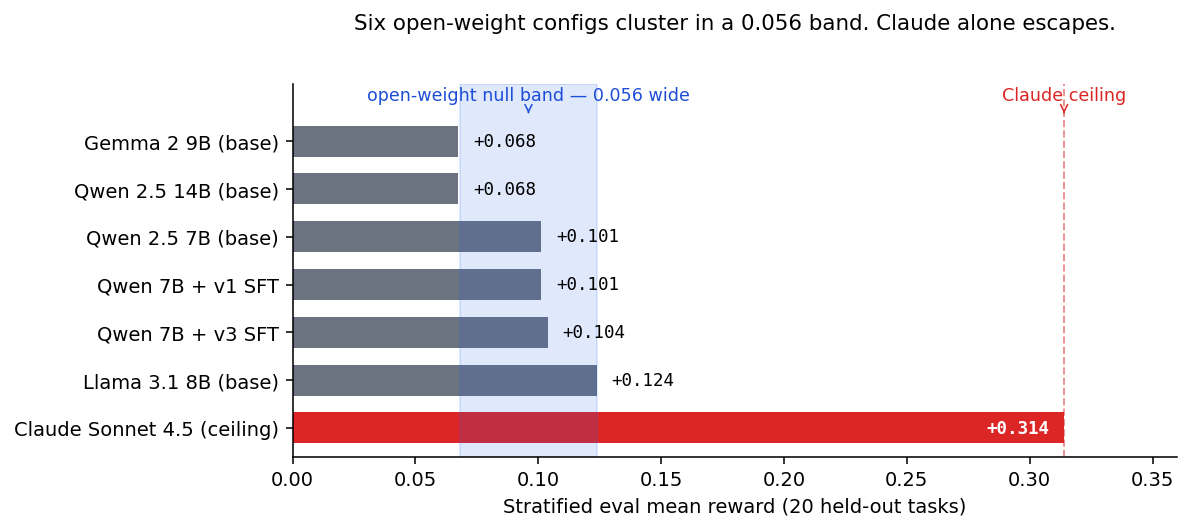

In [4]:
import matplotlib.pyplot as plt

labels = df["Model"].tolist()
vals = df["Eval mean"].tolist()
colors = ["#6b7280"] * (len(labels) - 1) + ["#dc2626"]  # Claude in red

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(labels, vals, color=colors)

# Null band (no legend — annotated directly above plot)
ax.axvspan(0.068, 0.124, alpha=0.12, color="#2563eb")
ax.axvline(0.314, color="#dc2626", linestyle="--", alpha=0.6)

# Headroom above first bar for annotations
ax.set_ylim(len(labels) - 0.4, -1.2)

# Annotations above plot area (no legend overlap)
ax.annotate("open-weight null band (0.056 wide)",
            xy=(0.096, -0.6), xytext=(0.096, -1.0),
            ha="center", fontsize=9, color="#1e40af",
            arrowprops=dict(arrowstyle="-", color="#1e40af", lw=0.8))
ax.annotate("Claude ceiling",
            xy=(0.314, -0.6), xytext=(0.314, -1.0),
            ha="center", fontsize=9, color="#dc2626",
            arrowprops=dict(arrowstyle="-", color="#dc2626", lw=0.8))

ax.set_xlabel("Stratified eval mean reward (20 held-out tasks)")
ax.set_title("Triple-family null — six open-weight configs cluster, Claude alone escapes")
ax.invert_yaxis()

# Value labels: open-weights at bar end, Claude in white inside bar
for b, v, label in zip(bars, vals, labels):
    if label.startswith("Claude"):
        ax.text(v - 0.005, b.get_y() + b.get_height()/2, f"{v:+.3f}",
                va="center", ha="right", fontsize=9, color="white", fontweight="bold")
    else:
        ax.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:+.3f}",
                va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 2.1 Failure-mode taxonomy

Same reward, different pathologies. The trajectory logs reveal **three distinct open-weight failure modes**:

| Mode | Models | Behavior |
|---|---|---|
| `frozen_loop` | Qwen 2.5 7B | Calls one or two tools, then repeats the same tool call across turns without updating state. Short trajectories (mean 4.95 turns). |
| `tool_spam` | Qwen 2.5 14B, Llama 3.1 8B | Fires lots of tool calls but ignores customer-specific evidence (allergen lists, party size, timestamp). 14B actually scores worse than 7B. |
| `chat_only` | Gemma 2 9B | Rarely calls tools; produces long, polite text. Scores **0.000** on `server_food_safety` — the only model above Claude's **−0.100** on that category — because the reward-dominant action there is *refuse + escalate*, which happens to match a "just apologize" prior. |

All three modes hit the same ~+0.10 ceiling — the reward surface doesn't reward any of them differentially, and none of them approximate what Claude does.


## 3. Per-category breakdown

The held-out set is stratified across 10 categories. Here's how each model places per category vs. Claude.


In [5]:
def per_cat(p):
    d = json.loads(p.read_text())
    out = {}
    for r in d["per_category"]:
        # v1 file uses "ours", base files use "base"
        score = r.get("ours", r.get("base"))
        out[r["category"]] = score
    return out

pc = {label: per_cat(p) for label, p in heldouts.items()}
# Claude value is the same across files (computed on the matched subset)
claude_pc = {r["category"]: r["claude"] for r in json.loads(heldouts["Qwen 7B base"].read_text())["per_category"]}

cats = list(claude_pc.keys())
cat_df = pd.DataFrame({"category": cats, "Claude": [round(claude_pc[c], 3) for c in cats]})
for label in heldouts:
    cat_df[label] = [round(pc[label].get(c, float("nan")), 3) for c in cats]
cat_df


,category,Claude,Qwen 7B base,Qwen 7B + v1 SFT,Qwen 7B + v3 SFT,Qwen 14B base,Llama 3.1 8B base,Gemma 2 9B base
0,host_phone,0.182,0.000,0.000,0.000,-0.033,-0.408,0.000
1,host_seating,0.175,0.100,0.100,0.000,-0.100,0.175,0.000
2,server_billing,0.450,0.450,0.450,0.000,0.450,-0.100,0.000
3,server_celebration,0.275,0.275,0.275,0.175,0.225,0.275,0.275
4,server_food_issue,1.075,0.225,0.225,0.225,0.225,0.225,0.000
5,server_food_safety,-0.100,-0.525,-0.525,0.000,-0.713,-0.438,0.000
6,server_incident,0.375,-0.333,-0.333,0.000,-0.300,0.450,0.000
7,server_misc,0.460,0.531,0.531,0.312,0.531,0.319,0.200
8,server_promotion,0.238,0.242,0.242,0.083,0.258,0.333,0.000
9,server_special_policy,0.275,0.175,0.175,0.175,0.075,0.375,0.275


### 3.1 Hero counter-example — Gemma 2 9B beats Claude on `server_food_safety`

Look at the `server_food_safety` row: **Gemma 0.000, Claude −0.100** (a +0.100 advantage for Gemma, the only model above Claude on this category). Gemma "wins" by doing less — its `chat_only` prior lands near the inaction-is-safe corner, which on this category out-scores a more aggressive agent. Claude's willingness to engage pushes it into partial-compliance penalties that Gemma avoids entirely by not engaging.

Why this matters: it's a concrete instance of the deeper problem — **the reward surface does not monotonically reward capability**. Capability can actually hurt you in categories where the dominant strategy is caution. Any scalable training signal has to break this.


## 4. v3 overfit — driving training loss 12× lower moved eval +0.003

> **Recipe versioning.** Three recipes were trained — **v1** (3 epochs, 40 trajectories, conservative), **v2** (5 epochs, 50 trajectories, aggressive), and **v3** (6 epochs, 30 steps on the clean stratified split, overfit stress test). v2 scored high on an early eval split that turned out to have train/eval task-ID overlap, so it was retired once the stratified split exposed the leakage — no comparable number on the held-out eval exists for it. The comparison below is **v1 (shipped) vs v3 (overfit stress test)** on the final stratified 20-task held-out set.

| Recipe | Epochs | Steps | Final train loss | Stratified eval | Δ vs base |
|---|---|---|---|---|---|
| **v1** (canonical, shipped) | 3 | 18 | **0.7559** | +0.1013 | +0.000 |
| **v3** (overfit stress test) | 6 | 30 | **0.0587** | +0.1038 | +0.003 |

The loss ratio is **12.9×**. The eval delta is **0.003**. Optimization and reward live on different manifolds — the supervised objective is **not** a proxy for the environment reward at this data scale.

This is not a tuning bug. It's the single most-informative signal from the whole V1 run.

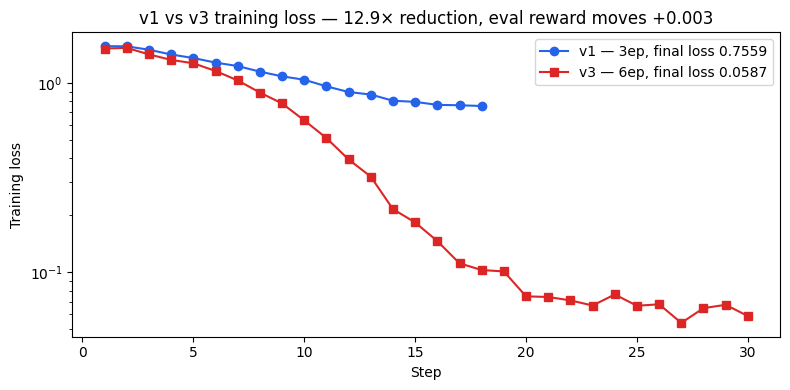

In [6]:
# Render the v1 vs v3 training curve from the checkpoint trainer_state.json files
v1_state = json.loads((ROOT / "checkpoints/v1/trainer_state.json").read_text())
v3_state = json.loads((ROOT / "checkpoints/v3/trainer_state.json").read_text())

def curve(state):
    xs, ys = [], []
    for entry in state["log_history"]:
        if "loss" in entry:
            xs.append(entry.get("step") or entry.get("epoch"))
            ys.append(entry["loss"])
    return xs, ys

v1x, v1y = curve(v1_state)
v3x, v3y = curve(v3_state)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v1x, v1y, "-o", label=f"v1 — 3ep, final loss {v1y[-1]:.4f}", color="#2563eb")
ax.plot(v3x, v3y, "-s", label=f"v3 — 6ep, final loss {v3y[-1]:.4f}", color="#dc2626")
ax.set_xlabel("Step")
ax.set_ylabel("Training loss")
ax.set_title("v1 vs v3 training loss — 12.9× reduction, eval reward moves +0.003")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()


## 4b. GRPO collapse — `reward_std = 0` at both 1.5B and 7B

Before landing on SFT as the canonical V1 release, two GRPO runs were executed along the DeepSeek-R1-style SFT-warmup-then-GRPO template. Both collapsed within the first 10–30 steps at `reward_std = 0` — no intra-group advantage signal at either scale.

| Attempt | Stack | Outcome |
|---|---|---|
| 1 | Qwen 2.5 1.5B + LoRA r=16, pure GRPO, T4 (Colab) | `reward_std = 0` from step 1; 100 steps of zero advantage |
| 2 | Qwen 2.5 7B + LoRA r=16, 1-epoch SFT warmup → GRPO, A100 (Colab PAYG) | `reward_std = 0` within ~30 steps; β·KL term was the only remaining gradient, which pulled the SFT adapter back toward base policy (GRPO actively *unlearning* the SFT warmup) |

**Mechanism.** GRPO computes advantage as

$$A_i = \frac{r_i - \mathrm{mean}(r_{1..K})}{\mathrm{std}(r_{1..K})}$$

over K rollouts per group. When a reward surface has too few distinct outcomes at the current policy's output distribution — which is exactly what 3.6 tasks/category + terminal-only reward produces — all K rollouts hit the same reward floor, the denominator is zero, and no policy gradient exists. The HF Trainer HTML progress bar does **not** surface this: `loss` still renders as small numbers because it is `policy_ratio × advantage + β·KL`, and `β·KL ≈ 0` on the first steps. `reward_std`, `grad_norm`, and `kl` must be read from `trainer.state.log_history` directly.

**Why this is the same root cause as the SFT null.** SFT sees the environment's insufficiency as a cross-entropy/reward decoupling (training loss drops 12.9× → eval moves +0.003). GRPO sees it as zero intra-group variance (rollouts are indistinguishable to the reward function). One environment, two canonical 2026 post-training methods, two different failure signatures, **same root**: the reward surface cannot separate agent behaviors at this data density.

Archived at `notebooks/_archive/train_qwen_grpo.py`, `train_qwen7b_sft_grpo.py`, `train_qwen7b_sft_grpo_v2.py`. Full diagnostic trail in `scratch/study_notes/03_dev_notes.md` §§负一, 负零点五, 负零点一.

## 5. Eight structural limitations — P0 → P3

The full P0-P3 taxonomy lives in the README. Short version: V1 is **benchmark-grade** (enough to rank models) but not **env-grade** (not enough for any model to learn within-class invariances).

| # | Limitation | Priority | V2 fix |
|---|---|---|---|
| 1 | ~10 tasks/category (ImageNet has ~1300) | **P0** | Scale to 50–100/cat via programmatic variants + seed rotation |
| 2 | Terminal-only reward (0/partial/1 at end) | **P0** | Dense per-turn shaping on ACTION hits |
| 3 | Inaction can Pareto-dominate (Gemma food_safety) | **P0** | Explicit penalty for under-tool-calling; safety-compliance gradient |
| 4 | 40 SFT traj × greedy eval → high variance | P1 | N=3 rollouts, temperature sampling, CI bands |
| 5 | No partial-credit for near-correct tool args | P1 | Arg-level fuzzy match reward |
| 6 | Single-thread rollout (no kitchen-floor parallelism) | P2 | Multi-agent floor simulator |
| 7 | Static customer simulators (no adversarial updates) | P2 | Online customer-model finetune |
| 8 | No long-horizon memory (shift-level planning) | P3 | Multi-hour shift episodes |

See the repo README `#what-we-learned` for the full write-up and V2 roadmap.


## 6. V2 roadmap — the vertical-composite thesis in action

**The core contribution of V1 is the null.** It empirically validates a specific thesis:

> Hospitality is a **vertical-composite** domain. Single-thread training on benchmark-scale task inventories (3.6 tasks/category) cannot close the gap to a frontier ceiling.
> **ImageNet-scale per-class density, not benchmark-scale breadth, is the path forward.**

V2 re-specifies data scale and reward surface along the lines V1 identified:

1. **Data scale:** 50–100 tasks/category via programmatic variants + seed rotation (→ P0 #1).
2. **Reward surface:** dense per-turn shaping + anti-inaction penalty + fuzzy-match arg rewards (→ P0 #2, #3; P1 #5).
3. **Eval hygiene:** N=3 sampled rollouts with CIs, per-category variance reported (→ P1 #4).
4. **Structural lifts:** multi-agent floor parallelism and shift-level memory for a later V3 (→ P2, P3).

The v1 adapter (this release) is the canonical "no-signal" baseline against which every V2 change will be measured.


## 7. Run the v1 adapter yourself

The LoRA adapter is on the Hub at [`binleiwang/qwen2.5-7b-hospitality-sft`](https://huggingface.co/binleiwang/qwen2.5-7b-hospitality-sft).

The cells below are **GPU-gated** — they load the base Qwen 2.5 7B Instruct in 4-bit and apply the LoRA. Skip them if running on CPU-only; the null-result story above is complete without them.


In [7]:
# GPU check — this cell is safe to run on CPU; it just reports status.
try:
    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("device:", torch.cuda.get_device_name(0))
except ImportError:
    print("torch not installed — skip §7 or `pip install torch transformers peft bitsandbytes`")


torch: 2.5.1
cuda available: False


In [8]:
# === GPU cell === (skip if torch.cuda.is_available() is False)
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from peft import PeftModel
#
# BASE = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"
# ADAPTER = "binleiwang/qwen2.5-7b-hospitality-sft"
#
# tok = AutoTokenizer.from_pretrained(BASE)
# model = AutoModelForCausalLM.from_pretrained(BASE, device_map="auto")
# model = PeftModel.from_pretrained(model, ADAPTER)
# model.eval()
#
# msgs = [
#     {"role": "system", "content": "You are a server at Berkeley Hot Pot."},
#     {"role": "user",   "content": "Hi, I have a severe peanut allergy — can I eat the satay broth?"},
# ]
# inputs = tok.apply_chat_template(msgs, return_tensors="pt", add_generation_prompt=True).to(model.device)
# out = model.generate(inputs, max_new_tokens=128, do_sample=False)
# print(tok.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))


For a full end-to-end rollout against the env (multi-turn, tool-calling, deterministic scoring), see `eval_v1_stratified.py` at the repo root — it's the exact script used to produce `evals/eval_heldout_v1_stratified.json` which this notebook reads.

---

**Contact / citation:** see the repo README. **License:** MIT for code and model card; base model retains its own license.
